# Task 2.2 Mining Cancer Feature Patterns

through sequential pattern mining

### Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('datasets/cancer_data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
print(df.isna().sum()) # check for empty values
duplicate_count = df.duplicated().sum() # check for duplicate rows
print(f"Number of duplicate rows: {duplicate_count}")

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [4]:
# remove empty irrelevant column
df.drop(columns=['Unnamed: 32'], inplace=True)  
# remove ID since it is irrelevant
df = df.drop(columns=['id'])

In [5]:
# Separate features (X) and target (y)
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

## Feature Transformation
### Discretizing Features
converting continuous values to categorical representations (low, medium, high)

we first use quantile strategy for binning, the other strategies will be explored below

In [6]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins = 3
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile', subsample=None)
X_discretized = discretizer.fit_transform(X)
X_discretized_df = pd.DataFrame(X_discretized, columns=X.columns, dtype=int)

bin_labels = {0: '_low', 1: '_medium', 2: '_high'}
for col in X_discretized_df.columns:
    X_discretized_df[col] = X_discretized_df[col].map(bin_labels)

print("\nDiscretized Features Head:")
print(X_discretized_df.head())


Discretized Features Head:
  radius_mean texture_mean perimeter_mean area_mean smoothness_mean  \
0       _high         _low          _high     _high           _high   
1       _high      _medium          _high     _high            _low   
2       _high        _high          _high     _high           _high   
3        _low      _medium           _low      _low           _high   
4       _high         _low          _high     _high         _medium   

  compactness_mean concavity_mean concave points_mean symmetry_mean  \
0            _high          _high               _high         _high   
1          _medium        _medium               _high       _medium   
2            _high          _high               _high         _high   
3            _high          _high               _high         _high   
4            _high          _high               _high       _medium   

  fractal_dimension_mean  ... radius_worst texture_worst perimeter_worst  \
0                  _high  ...        _high

### Defining the Sequence Semantics

mutual information

In [7]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X.columns)
sorted_features_by_mi = mi_scores_series.sort_values(ascending=False)

print("\nTop 10 Features by Mutual Information:")
print(sorted_features_by_mi.head(10))
ranked_feature_names = sorted_features_by_mi.index.tolist()


Top 10 Features by Mutual Information:
perimeter_worst         0.471842
area_worst              0.464313
radius_worst            0.451230
concave points_mean     0.438806
concave points_worst    0.436255
perimeter_mean          0.402361
concavity_mean          0.375447
radius_mean             0.362276
area_mean               0.360023
area_se                 0.340759
dtype: float64


### Create Sequential Representations 
(rank features by their mutual importance)

In [17]:
L = 10  # maximum sequence length

patient_sequences = []

for i in range(len(df)):
    patient_sequence = []
    patient_discretized_values = X_discretized_df.iloc[i]

    prev_score = None
    current_itemset = []

    for feature_name in ranked_feature_names[:L]:
        discretized_value = patient_discretized_values[feature_name]
        # create token (eg'perimeter_worst_high')
        token = f"{feature_name}{discretized_value}"
        current_score = mi_scores_series[feature_name]

        # if feature has the same MI score as the previous one
        # group it into the same itemset (same order tie)
        if prev_score is not None and abs(current_score - prev_score) < 1e-9:
            current_itemset.append(token)
        else:
            if current_itemset:
                # convert itemset to tuple before appending
                patient_sequence.append(tuple(current_itemset))
            current_itemset = [token]
        prev_score = current_score

    # Append the last itemset
    if current_itemset:
        patient_sequence.append(tuple(current_itemset))

    patient_sequences.append(patient_sequence)

df_sequences = pd.DataFrame({
    'diagnosis': y,
    'sequence': patient_sequences
})

malignant_sequences = df_sequences[df_sequences['diagnosis'] == 1]['sequence'].tolist()
benign_sequences    = df_sequences[df_sequences['diagnosis'] == 0]['sequence'].tolist()

print(f"Created {len(malignant_sequences)} malignant sequences.")
print(f"Created {len(benign_sequences)} benign sequences.")
print("\nExample Malignant Sequence:")
print(malignant_sequences[0])
print("\nExample Benign Sequence:")
print(benign_sequences[0])

Created 212 malignant sequences.
Created 357 benign sequences.

Example Malignant Sequence:
[('perimeter_worst_high',), ('area_worst_high',), ('radius_worst_high',), ('concave points_mean_high',), ('concave points_worst_high',), ('perimeter_mean_high',), ('concavity_mean_high',), ('radius_mean_high',), ('area_mean_high',), ('area_se_high',)]

Example Benign Sequence:
[('perimeter_worst_medium',), ('area_worst_medium',), ('radius_worst_medium',), ('concave points_mean_medium',), ('concave points_worst_medium',), ('perimeter_mean_medium',), ('concavity_mean_medium',), ('radius_mean_medium',), ('area_mean_medium',), ('area_se_medium',)]


## Applying GSP (Generalized Sequential Pattern)

### GSP Algorithm

In [28]:
from itertools import combinations

def get_support(candidate, sequences):
    """
    Count how many sequences contain the candidate subsequence.
    (This function is correct and remains unchanged)
    """
    count = 0
    for seq in sequences:
        pos = 0
        for item in candidate:
            try:
                pos = seq.index(item, pos) + 1
            except ValueError:
                break
        else:
            count += 1
    return count / len(sequences)

def generate_candidates_gsp(frequents):
    candidates = set()
    k_minus_1_length = len(frequents[0])
    
    for i in range(len(frequents)):
        for j in range(len(frequents)):
            s1 = frequents[i]
            s2 = frequents[j]
            
            # GSP Join Condition: s1[1:] == s2[:-1]
            # s1 with its first item dropped must equal s2 with its last item dropped
            if s1[1:] == s2[:-1]:
                # New candidate is formed by concatenating s1 and the last element of s2
                new_candidate = s1 + [s2[-1]]
                candidates.add(tuple(new_candidate))
                
    return [list(c) for c in candidates]

def prune_candidates(candidates, frequents_set, k):
    """
    prune candidates if any of their (k-1) subsequences is infrequent.
    frequents_set must contain all k-1 frequent patterns as tuples.
    """
    pruned_candidates = []
    
    for candidate in candidates:
        is_valid = True
        
        for i in range(k): 
            # subsequence is the candidate with the item at index i removed
            subsequence = tuple(candidate[:i] + candidate[i+1:])
            
            if subsequence not in frequents_set:
                is_valid = False
                break
        
        if is_valid:
            pruned_candidates.append(candidate)
            
    return pruned_candidates


def gsp(sequences, min_support=0.3):
    frequent_patterns = []

    # first generate 1-item frequent sequences
    items = sorted(set(item for seq in sequences for item in seq))
    freq_1 = [[item] for item in items if get_support([item], sequences) >= min_support]
    frequent_patterns.extend(freq_1)

    k = 2
    current_frequents = freq_1

    while current_frequents:
        current_frequents_set = set(tuple(f) for f in current_frequents)

        candidates = generate_candidates_gsp(current_frequents)
   
        candidates = prune_candidates(candidates, current_frequents_set, k)

        current_frequents = [
            c for c in candidates if get_support(c, sequences) >= min_support
        ]

        frequent_patterns.extend(current_frequents)
        k += 1

    return frequent_patterns

We will first mine the sequential patterns without constraints, to allow us to get a complete picture of sequence relationships.

After which, we would then postprocess the discovered patterns to reduce redundancy in the patterns mined.

In [27]:
min_support = 0.3

malignant_frequent = gsp(malignant_sequences, min_support)
benign_frequent = gsp(benign_sequences, min_support)

print(f"Found {len(malignant_frequent)} frequent malignant patterns.")
print(f"Found {len(benign_frequent)} frequent benign patterns.")

print("\nTop 100 malignant frequent patterns:")
for p in malignant_frequent[:100]:
    pattern_str = " → ".join([",".join(item) for item in p])
    print("  ", pattern_str)

Found 1023 frequent malignant patterns.
Found 290 frequent benign patterns.

Top 100 malignant frequent patterns:
   area_mean_high
   area_se_high
   area_worst_high
   concave points_mean_high
   concave points_worst_high
   concavity_mean_high
   perimeter_mean_high
   perimeter_worst_high
   radius_mean_high
   radius_worst_high
   area_worst_high → perimeter_mean_high
   perimeter_mean_high → area_mean_high
   perimeter_worst_high → concave points_mean_high
   perimeter_worst_high → radius_worst_high
   perimeter_mean_high → radius_mean_high
   radius_worst_high → concave points_mean_high
   perimeter_worst_high → radius_mean_high
   perimeter_worst_high → concave points_worst_high
   perimeter_worst_high → concavity_mean_high
   concave points_mean_high → radius_mean_high
   concave points_mean_high → concave points_worst_high
   concave points_worst_high → radius_mean_high
   concave points_mean_high → concavity_mean_high
   radius_worst_high → radius_mean_high
   concave points

#### To find most suitable minimum support 

try across different minsup thresholds

support_values = [0.2, 0.3, 0.4, 0.5]

- Higher min support → fewer, stronger patterns (more general)
- Lower min support → more, weaker patterns (more specific, maybe noisy)


Support = 0.1
  Malignant patterns: 1210
  Benign patterns: 2577

Support = 0.2
  Malignant patterns: 1023
  Benign patterns: 808

Support = 0.3
  Malignant patterns: 1023
  Benign patterns: 290

Support = 0.4
  Malignant patterns: 1023
  Benign patterns: 83

Support = 0.5
  Malignant patterns: 1023
  Benign patterns: 15


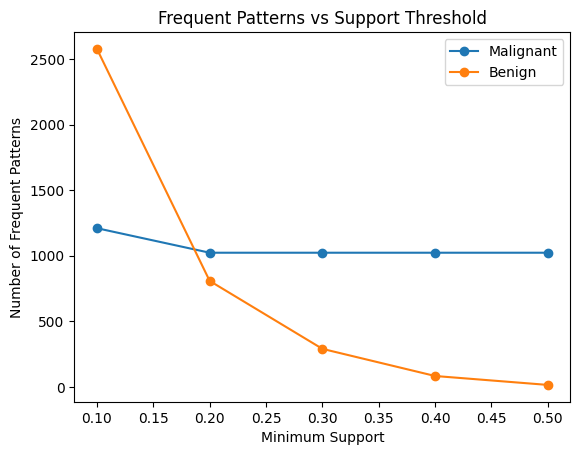

In [29]:
results = []
support_values = [0.1, 0.2, 0.3, 0.4, 0.5]

for min_support in support_values:
    malignant_frequent = gsp(malignant_sequences, min_support)
    benign_frequent = gsp(benign_sequences, min_support)

    results.append({
        'support': min_support,
        'malignant_count': len(malignant_frequent),
        'benign_count': len(benign_frequent)
    })

    print(f"\nSupport = {min_support}")
    print(f"  Malignant patterns: {len(malignant_frequent)}")
    print(f"  Benign patterns: {len(benign_frequent)}")

import matplotlib.pyplot as plt

supports = [r['support'] for r in results]
malignant_counts = [r['malignant_count'] for r in results]
benign_counts = [r['benign_count'] for r in results]

plt.plot(supports, malignant_counts, marker='o', label='Malignant')
plt.plot(supports, benign_counts, marker='o', label='Benign')
plt.xlabel('Minimum Support')
plt.ylabel('Number of Frequent Patterns')
plt.title('Frequent Patterns vs Support Threshold')
plt.legend()
plt.show()

For malignant patterns, it mostly remains constant after 0.2 threshold. But for benign patterns it drops sharply as support increases.
Many benign patterns are rare, so high thresholds prune aggressively.

A good balance of support would be **0.3**, where malignant patterns are retained but benign patterns are filtered can help find discriminative patterns.

### Pattern Postprocessing

- first try mining only the closed frequent patterns
    - an itemset is closed if none of its immediate supersets has the same support as it 

In [31]:
def closed_patterns(frequent_patterns, sequences):
    """
    Given a list of frequent patterns and the sequences they come from,
    return only the closed patterns.
    """
    # compute support for all patterns
    pattern_support = {tuple(map(tuple, p)): get_support(p, sequences) for p in frequent_patterns}

    closed_patterns = []

    for p1 in pattern_support:
        is_closed = True
        for p2 in pattern_support:
            if p1 == p2:
                continue
            # p1 is a subsequence of p2 and has the same support → not closed
            if is_subsequence(p1, p2) and pattern_support[p1] == pattern_support[p2]:
                is_closed = False
                break
        if is_closed:
            closed_patterns.append(list(p1))

    return closed_patterns


def is_subsequence(subseq, seq):
    pos = 0
    for itemset in subseq:
        try:
            pos = seq.index(itemset, pos) + 1
        except ValueError:
            return False
    return True

In [39]:
min_support = 0.3

# Mine frequent patterns
malignant_frequent = gsp(malignant_sequences, min_support)
benign_frequent = gsp(benign_sequences, min_support)

# Filter closed patterns
malignant_closed = closed_patterns(malignant_frequent, malignant_sequences)
benign_closed = closed_patterns(benign_frequent, benign_sequences)

# Compute support for each pattern and sort
malignant_closed_with_support = [(p, get_support(p, malignant_sequences)) for p in malignant_closed]
malignant_closed_with_support.sort(key=lambda x: x[1], reverse=True)  # sort by support descending

benign_closed_with_support = [(p, get_support(p, benign_sequences)) for p in benign_closed]
benign_closed_with_support.sort(key=lambda x: x[1], reverse=True)

print(f"Closed malignant patterns: {len(malignant_closed)}")
print(f"Closed benign patterns: {len(benign_closed)}\n")

print("Top 20 malignant closed frequent patterns (sorted by support):")
for p, s in malignant_closed_with_support[:20]:
    pattern_str = " → ".join([",".join(item) for item in p])
    print(f"  {pattern_str}  (support={s:.2f})")

print("\nTop 20 benign closed frequent patterns (sorted by support):")
for p, s in benign_closed_with_support[:20]:
    pattern_str = " → ".join([",".join(item) for item in p])
    print(f"  {pattern_str}  (support={s:.2f})")

Closed malignant patterns: 188
Closed benign patterns: 143

Top 20 malignant closed frequent patterns (sorted by support):
  radius_worst_high  (support=0.84)
  concave points_worst_high  (support=0.84)
  perimeter_worst_high  (support=0.84)
  area_worst_high → radius_worst_high  (support=0.83)
  perimeter_worst_high → radius_worst_high  (support=0.82)
  concave points_mean_high  (support=0.82)
  perimeter_worst_high → area_worst_high → radius_worst_high  (support=0.81)
  perimeter_mean_high  (support=0.80)
  area_mean_high  (support=0.79)
  concavity_mean_high  (support=0.79)
  radius_mean_high  (support=0.79)
  perimeter_mean_high → radius_mean_high  (support=0.78)
  concave points_mean_high → concave points_worst_high  (support=0.78)
  radius_mean_high → area_mean_high  (support=0.78)
  perimeter_worst_high → perimeter_mean_high  (support=0.78)
  area_worst_high → radius_worst_high → perimeter_mean_high  (support=0.78)
  perimeter_mean_high → radius_mean_high → area_mean_high  (supp

### Sensitivity Check across different binning methods during discretization

#### Uniform

In [42]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins = 3
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform', subsample=None)
X_discretized = discretizer.fit_transform(X)
X_discretized_df = pd.DataFrame(X_discretized, columns=X.columns, dtype=int)

bin_labels = {0: '_low', 1: '_medium', 2: '_high'}
for col in X_discretized_df.columns:
    X_discretized_df[col] = X_discretized_df[col].map(bin_labels)

print("\nDiscretized Features Head:")
print(X_discretized_df.head())

L = 10  # maximum sequence length

patient_sequences = []

for i in range(len(df)):
    patient_sequence = []
    patient_discretized_values = X_discretized_df.iloc[i]

    prev_score = None
    current_itemset = []

    for feature_name in ranked_feature_names[:L]:
        discretized_value = patient_discretized_values[feature_name]
        # create token (eg'perimeter_worst_high')
        token = f"{feature_name}{discretized_value}"
        current_score = mi_scores_series[feature_name]

        # if feature has the same MI score as the previous one
        # group it into the same itemset (same order tie)
        if prev_score is not None and abs(current_score - prev_score) < 1e-9:
            current_itemset.append(token)
        else:
            if current_itemset:
                # convert itemset to tuple before appending
                patient_sequence.append(tuple(current_itemset))
            current_itemset = [token]
        prev_score = current_score

    # Append the last itemset
    if current_itemset:
        patient_sequence.append(tuple(current_itemset))

    patient_sequences.append(patient_sequence)

df_sequences = pd.DataFrame({
    'diagnosis': y,
    'sequence': patient_sequences
})

malignant_sequences = df_sequences[df_sequences['diagnosis'] == 1]['sequence'].tolist()
benign_sequences    = df_sequences[df_sequences['diagnosis'] == 0]['sequence'].tolist()

print(f"Created {len(malignant_sequences)} malignant sequences.")
print(f"Created {len(benign_sequences)} benign sequences.")
print("\nExample Malignant Sequence:")
print(malignant_sequences[0])
print("\nExample Benign Sequence:")
print(benign_sequences[0])

min_support = 0.3

# Mine frequent patterns
malignant_frequent = gsp(malignant_sequences, min_support)
benign_frequent = gsp(benign_sequences, min_support)

# Filter closed patterns
malignant_closed = closed_patterns(malignant_frequent, malignant_sequences)
benign_closed = closed_patterns(benign_frequent, benign_sequences)

# Compute support for each pattern and sort
malignant_closed_with_support = [(p, get_support(p, malignant_sequences)) for p in malignant_closed]
malignant_closed_with_support.sort(key=lambda x: x[1], reverse=True)  # sort by support descending

benign_closed_with_support = [(p, get_support(p, benign_sequences)) for p in benign_closed]
benign_closed_with_support.sort(key=lambda x: x[1], reverse=True)

print(f"Closed malignant patterns: {len(malignant_closed)}")
print(f"Closed benign patterns: {len(benign_closed)}\n")

print("Top 20 malignant closed frequent patterns (sorted by support):")
for p, s in malignant_closed_with_support[:20]:
    pattern_str = " → ".join([",".join(item) for item in p])
    print(f"  {pattern_str}  (support={s:.2f})")

print("\nTop 20 benign closed frequent patterns (sorted by support):")
for p, s in benign_closed_with_support[:20]:
    pattern_str = " → ".join([",".join(item) for item in p])
    print(f"  {pattern_str}  (support={s:.2f})")


Discretized Features Head:
  radius_mean texture_mean perimeter_mean area_mean smoothness_mean  \
0     _medium         _low        _medium   _medium         _medium   
1     _medium         _low        _medium   _medium            _low   
2     _medium      _medium        _medium   _medium         _medium   
3        _low      _medium           _low      _low           _high   
4     _medium         _low        _medium   _medium         _medium   

  compactness_mean concavity_mean concave points_mean symmetry_mean  \
0            _high          _high               _high         _high   
1             _low           _low             _medium       _medium   
2          _medium        _medium             _medium       _medium   
3            _high        _medium             _medium         _high   
4          _medium        _medium             _medium       _medium   

  fractal_dimension_mean  ... radius_worst texture_worst perimeter_worst  \
0                _medium  ...      _medium

#### K-Means

In [44]:
from sklearn.preprocessing import KBinsDiscretizer

n_bins = 3
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='kmeans', subsample=None)
X_discretized = discretizer.fit_transform(X)
X_discretized_df = pd.DataFrame(X_discretized, columns=X.columns, dtype=int)

bin_labels = {0: '_low', 1: '_medium', 2: '_high'}
for col in X_discretized_df.columns:
    X_discretized_df[col] = X_discretized_df[col].map(bin_labels)

print("\nDiscretized Features Head:")
print(X_discretized_df.head())

L = 10  # maximum sequence length

patient_sequences = []

for i in range(len(df)):
    patient_sequence = []
    patient_discretized_values = X_discretized_df.iloc[i]

    prev_score = None
    current_itemset = []

    for feature_name in ranked_feature_names[:L]:
        discretized_value = patient_discretized_values[feature_name]
        # create token (eg'perimeter_worst_high')
        token = f"{feature_name}{discretized_value}"
        current_score = mi_scores_series[feature_name]

        # if feature has the same MI score as the previous one
        # group it into the same itemset (same order tie)
        if prev_score is not None and abs(current_score - prev_score) < 1e-9:
            current_itemset.append(token)
        else:
            if current_itemset:
                # convert itemset to tuple before appending
                patient_sequence.append(tuple(current_itemset))
            current_itemset = [token]
        prev_score = current_score

    # Append the last itemset
    if current_itemset:
        patient_sequence.append(tuple(current_itemset))

    patient_sequences.append(patient_sequence)

df_sequences = pd.DataFrame({
    'diagnosis': y,
    'sequence': patient_sequences
})

malignant_sequences = df_sequences[df_sequences['diagnosis'] == 1]['sequence'].tolist()
benign_sequences    = df_sequences[df_sequences['diagnosis'] == 0]['sequence'].tolist()

print(f"Created {len(malignant_sequences)} malignant sequences.")
print(f"Created {len(benign_sequences)} benign sequences.")
print("\nExample Malignant Sequence:")
print(malignant_sequences[0])
print("\nExample Benign Sequence:")
print(benign_sequences[0])

min_support = 0.3

# Mine frequent patterns
malignant_frequent = gsp(malignant_sequences, min_support)
benign_frequent = gsp(benign_sequences, min_support)

# Filter closed patterns
malignant_closed = closed_patterns(malignant_frequent, malignant_sequences)
benign_closed = closed_patterns(benign_frequent, benign_sequences)

# Compute support for each pattern and sort
malignant_closed_with_support = [(p, get_support(p, malignant_sequences)) for p in malignant_closed]
malignant_closed_with_support.sort(key=lambda x: x[1], reverse=True)  # sort by support descending

benign_closed_with_support = [(p, get_support(p, benign_sequences)) for p in benign_closed]
benign_closed_with_support.sort(key=lambda x: x[1], reverse=True)

print(f"Closed malignant patterns: {len(malignant_closed)}")
print(f"Closed benign patterns: {len(benign_closed)}\n")

print("Top 20 malignant closed frequent patterns (sorted by support):")
for p, s in malignant_closed_with_support[:20]:
    pattern_str = " → ".join([",".join(item) for item in p])
    print(f"  {pattern_str}  (support={s:.2f})")

print("\nTop 20 benign closed frequent patterns (sorted by support):")
for p, s in benign_closed_with_support[:20]:
    pattern_str = " → ".join([",".join(item) for item in p])
    print(f"  {pattern_str}  (support={s:.2f})")


Discretized Features Head:
  radius_mean texture_mean perimeter_mean area_mean smoothness_mean  \
0       _high         _low          _high   _medium           _high   
1       _high      _medium          _high   _medium            _low   
2       _high      _medium          _high   _medium           _high   
3        _low      _medium           _low      _low           _high   
4       _high         _low          _high   _medium         _medium   

  compactness_mean concavity_mean concave points_mean symmetry_mean  \
0            _high          _high               _high         _high   
1             _low        _medium             _medium       _medium   
2          _medium        _medium               _high       _medium   
3            _high          _high             _medium         _high   
4          _medium        _medium             _medium       _medium   

  fractal_dimension_mean  ... radius_worst texture_worst perimeter_worst  \
0                  _high  ...        _high